In [8]:
## Day 11
## Hour 1
## Block 1
import pandas as pd
df=pd.read_csv('house_price_cleaned_v2.csv')
df.head()
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodD

In [9]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Luxury,Price_per_sqft
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,2,2008,WD,Normal,208500,0,121.929825
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,5,2007,WD,Normal,181500,0,143.819334
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,9,2008,WD,Normal,223500,0,125.139978
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,2,2006,WD,Abnorml,140000,0,81.537566
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,12,2008,WD,Normal,250000,0,113.739763


In [26]:
## Feature creation
## Type 1 Mathematical Features

## Total square footage of the house
df['TotalSF'] = df['TotalBsmtSF'] + df['GrLivArea']

## Total bathrqooms in the house
df['TotalBathrooms'] = df['FullBath'] + (0.5 * df['HalfBath']) 
+ df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])

## Ratio Features

## Price per square foot
df['Price_per_sqft'] = df['SalePrice'] / df['GrLivArea']

## Area per room
df['area_per_room'] = df['GrLivArea'] / (df['TotRmsAbvGrd'] + 1) 
# Adding 1 to avoid division by zero

## Type 3 - Interaction Features
df['quality_area'] = df['OverallQual'] * df['GrLivArea']

## Type 4 - Age Features
df['house_age'] = df['YrSold'] - df['YearBuilt']

## Renovation age
df['renovation_age'] = df['YrSold'] - df['YearRemodAdd']

## Binary Features
## Has garage or not
df['has_garage'] = df['GarageArea'].apply(lambda x: 1 if x > 0 else 0)

## Has basement or not
df['has_basement'] = df['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)

## Rooms per area
df['rooms_per_area'] = df['TotRmsAbvGrd'] / (df['GrLivArea'] + 1)  # Adding 1 to avoid division by zero

## Relative features
df['price_diff'] = df['SalePrice'] - df.groupby('Neighborhood')['SalePrice'].transform('mean')

## Binning 
df['area_segment'] = pd.qcut(df['GrLivArea'], q=3)

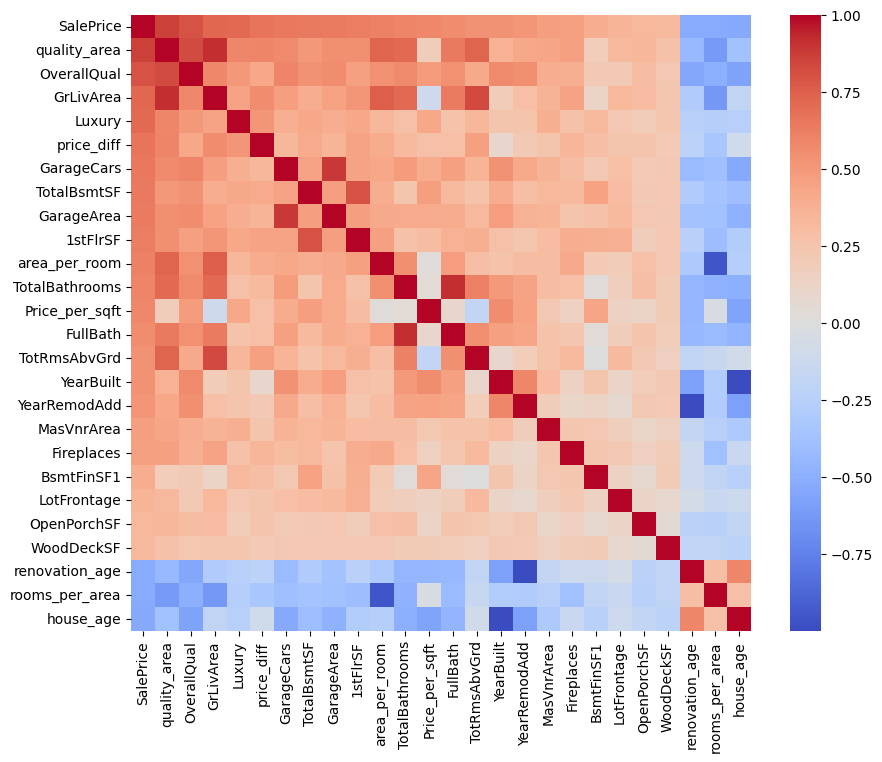

SalePrice         1.000000
quality_area      0.864957
OverallQual       0.800858
GrLivArea         0.720516
Luxury            0.715710
price_diff        0.667931
GarageCars        0.649256
TotalBsmtSF       0.646584
GarageArea        0.636964
1stFlrSF          0.625235
area_per_room     0.611943
TotalBathrooms    0.597292
Price_per_sqft    0.584318
FullBath          0.559048
TotRmsAbvGrd      0.537462
YearBuilt         0.535279
YearRemodAdd      0.521428
MasVnrArea        0.473650
Fireplaces        0.466765
BsmtFinSF1        0.395923
LotFrontage       0.354554
OpenPorchSF       0.330361
WoodDeckSF        0.322538
renovation_age   -0.523102
rooms_per_area   -0.529689
house_age        -0.535507
Name: SalePrice, dtype: float64

In [64]:
## Hour - 3
# Feature selection
# Block - 1

## 1. Domain Knowledge
## Drop ID
# df=df.drop(columns=['Id'],axis=1)

## 2. Correlation Based
# corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
# print(corr.head(10))
## GrLivArea is almost equal to TotalSF
# df = df.drop(columns=['TotalSF'])

## 4 low variance features - if a feature has the same
#  value for 99% of the data, it is not useful for prediction

# pd.set_option('display.max_rows', None)  # To display all rows
# print(df.nunique().sort_values().to_frame('unique_count'))

## How to check for low variance features?
## We can use the nunique() function to check the number of unique values in each column    
## Process 1
# df['Utilities'].value_counts(normalize=True)
# for col in df.columns:
#     print(f"{col}: {df[col].value_counts(normalize=True)}")

## Advanced dominance check
low_var_cols = [
    col for col in df.columns
    if df[col].value_counts(normalize=True).max() > 0.95
]
# print(f"Low variance columns: {low_var_cols}")

# for col in low_var_cols:
#     print(f"{col}: {df[col].value_counts(normalize=True)}")
#     print("-"*40)

# col_to_drop = ['Utilities','Condition2','RoofMatl',
#                'LowQualFinSF','3SsnPorch','PoolArea','MiscVal']
# df = df.drop(columns=col_to_drop)

# Missing Value Heavy Columns
## If missing>80% then drop the column
## Step 1 - Drop useless columns - Like Id
## Step -2
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr
## make a list of important features based on correlation
important_features = corr[abs(corr) > 0.3].index
df=df[important_features]

## Step -3 REmove Multicollinear features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr

In [85]:
## Removing duplicates
duplicate_cols = ['TotalBsmtSF','GarageArea','YearBuilt',
                  'YearRemodAdd','MasVnrArea','Fireplaces',
                  'BsmtFinSF1','LotFrontage','OpenPorchSF',
                  'WoodDeckSF','1stFlrSF','FullBath']
# df=df.drop(columns=duplicate_cols)
df.columns
df.shape

(1456, 12)

In [77]:
# df=df.drop(columns=['Luxury','TotRmsAbvGrd'])
df.to_csv('house_price_v5_selected.csv', index=False)

In [ ]:
## Hour 4
df1 = pd.read_csv('house_price_cleaned_v2.csv')
df1['TotalSF'] = df1['TotalBsmtSF'] + df['GrLivArea']

df1['TotalBathrooms'] = (
    df1['FullBath'] +
    0.5 * df1['HalfBath'] +
    df1['BsmtFullBath'] +
    0.5 * df1['BsmtHalfBath']

)
df1['Price_per_sqft'] = df1['SalePrice'] / df1['GrLivArea']
df1['area_per_room'] = df1['GrLivArea'] / (df1['TotRmsAbvGrd'] + 1)

df1['quality_area'] = df1['OverallQual'] * df1['GrLivArea']
df1['house_age'] = df1['YrSold'] - df1['YearBuilt']
df1['renovation_age'] = df1['YrSold'] - df1['YearRemodAdd']
df1['has_garage'] = (df1['GarageArea'] > 0).astype(int)
df1['has_basement'] = (df1['TotalBsmtSF'] > 0).astype(int)
low_var_cols = [
    'Utilities','Condition2','RoofMatl',
    '3SsnPorch','PoolArea','MiscVal','LowQualFinSF'
]

df1 = df1.drop(columns=low_var_cols, errors='ignore')
duplicate_cols = [
    'TotalBsmtSF','GarageArea','YearBuilt','YearRemodAdd',
    '1stFlrSF','FullBath'
]

df1 = df1.drop(columns=duplicate_cols, errors='ignore')
corr = df1.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

important_cols = corr[abs(corr) > 0.3].index

df1 = df1[important_cols]
print(df.shape)
df.head()

df.to_csv("house_price_v5_final.csv", index=False)

(1456, 12)


In [108]:
## Hour 5
df=pd.read_csv('house_price_v5_final.csv')
df.isnull().sum()
df.shape
df.columns
## Remove  target leakage features
leakage_cols = ['price_per_sqft','price_diff','Luxury']

df = df.drop(columns=leakage_cols, errors='ignore')
# df=df.drop('price_per_sqft', axis=1, inplace=True, errors='ignore')
df.columns
df = df.drop(columns=['Price_per_sqft'])
df.columns
df = df.drop(columns=['rooms_per_area'])
df.columns
df.shape

x = df.drop('SalePrice', axis=1)
y = df['SalePrice']
df.to_csv("house_price_v5_ml_ready.csv", index=False)
df.columns

Index(['SalePrice', 'quality_area', 'OverallQual', 'GrLivArea', 'GarageCars',
       'area_per_room', 'TotalBathrooms', 'renovation_age', 'house_age'],
      dtype='object')

In [110]:
## Hour 6
## How to get important features from a model?
# Random Forest (best for feature importance)
from sklearn.ensemble import RandomForestRegressor

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
# Block 3 — Extract Feature Importance
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)
print(df.shape)

quality_area      0.743356
house_age         0.067153
OverallQual       0.048778
area_per_room     0.035888
GrLivArea         0.031588
renovation_age    0.029465
GarageCars        0.028001
TotalBathrooms    0.015772
dtype: float64
(1456, 9)


In [118]:
# df = df.drop(columns=['OverallQual','GrLivArea'])
# df = df.drop(columns=['TotalBathrooms'])
df.columns

Index(['SalePrice', 'quality_area', 'GarageCars', 'area_per_room',
       'renovation_age', 'house_age'],
      dtype='object')

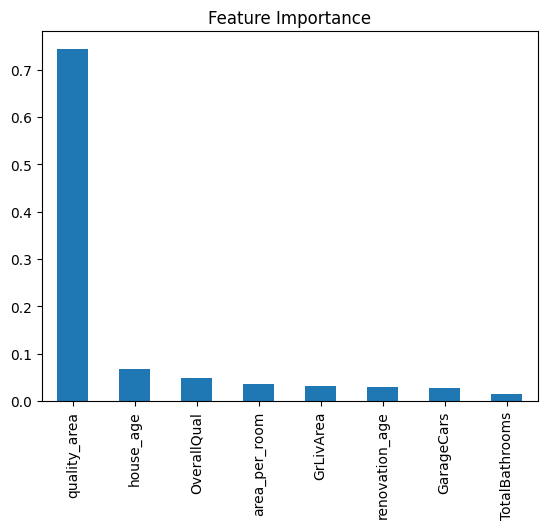

In [119]:
## Block 4
import matplotlib.pyplot as plt

importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [120]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [121]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

quality_area      0.788005
house_age         0.082134
area_per_room     0.051841
renovation_age    0.040131
GarageCars        0.037890
dtype: float64

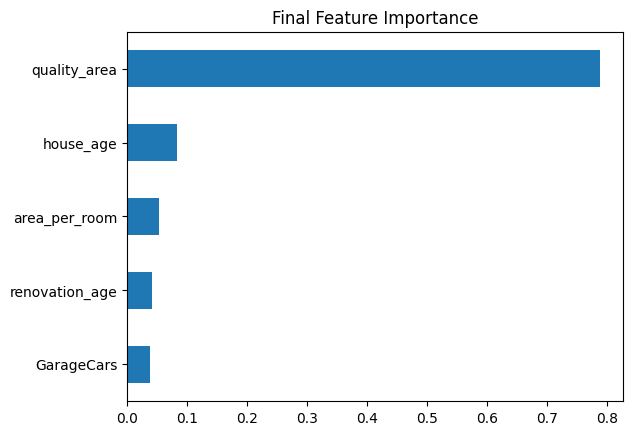

In [122]:
importance.sort_values().plot(kind='barh')
plt.title("Final Feature Importance")
plt.show()

In [ ]:
## Final save
df.to_csv("house_price_final_features.csv", index=False)
importance.to_csv("feature_importance_final.csv")


In [126]:
## Hour 8
df.isnull().sum()
# Final split
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
X.to_csv("X_final.csv", index=False)
y.to_csv("y_final.csv", index=False)

Final Features Description:

quality_area → combined effect of quality and area  
GarageCars → garage capacity  
area_per_room → space efficiency  
renovation_age → years since renovation  
house_age → age of house